In [17]:
# Install the package (uncomment if not already installed)
#!pip install git+https://github.com/sebastianprobst/resonator_tools.git

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resonator_tools import circuit

In [19]:
# Replace the filename with your actual file path
file_path = 'Data2/resontors_TWPA_off_S21_4.82-4.86GHz_-10.0dBm_20260716_143442.csv'
df = pd.read_csv(file_path)

# Convert units
freq = df['Frequency (GHz)'].values * 1e9
mag_lin = 10**(df['Magnitude (dB)'].values / 20)
phase_rad = np.deg2rad(df['Phase (deg)'].values)
s21_complex = mag_lin * np.exp(1j * phase_rad)

dict_keys(['Qi_dia_corr', 'Qi_no_corr', 'absQc', 'Qc_dia_corr', 'Ql', 'fr', 'theta0', 'phi0', 'phi0_err', 'Ql_err', 'absQc_err', 'fr_err', 'chi_square', 'Qi_no_corr_err', 'Qi_dia_corr_err'])
Ql            = 2.29e+03
Qc (absQc)    = 2.55e+03
Qc (dia corr) = 2.84e+03
Qi (no corr)  = 2.23e+04
Qi (dia corr) = 1.18e+04


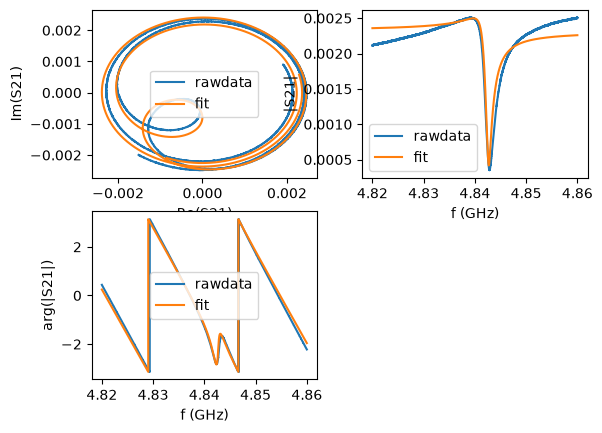

In [ ]:
fit = circuit.notch_port()
fit.add_data(freq, s21_complex)

fit.autofit()

print(f"Ql            = {fit.fitresults['Ql']:.2e}")
print(f"Qc (absQc)    = {fit.fitresults['absQc']:.2e}")
print(f"Qc (dia corr) = {fit.fitresults['Qc_dia_corr']:.2e}")
print(f"Qi (no corr)  = {fit.fitresults['Qi_no_corr']:.2e}")
print(f"Qi (dia corr) = {fit.fitresults['Qi_dia_corr']:.2e}")

fit.plotall()

c:\Users\Benji\Resonator-Frequency-Simulation\.venv\Lib\site-packages\resonator_tools\circlefit.py:379: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x0 = spopt.fsolve(func, 0.0, fprime=d_func)
c:\Users\Benji\Resonator-Frequency-Simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Benji\Resonator-Frequency-Simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


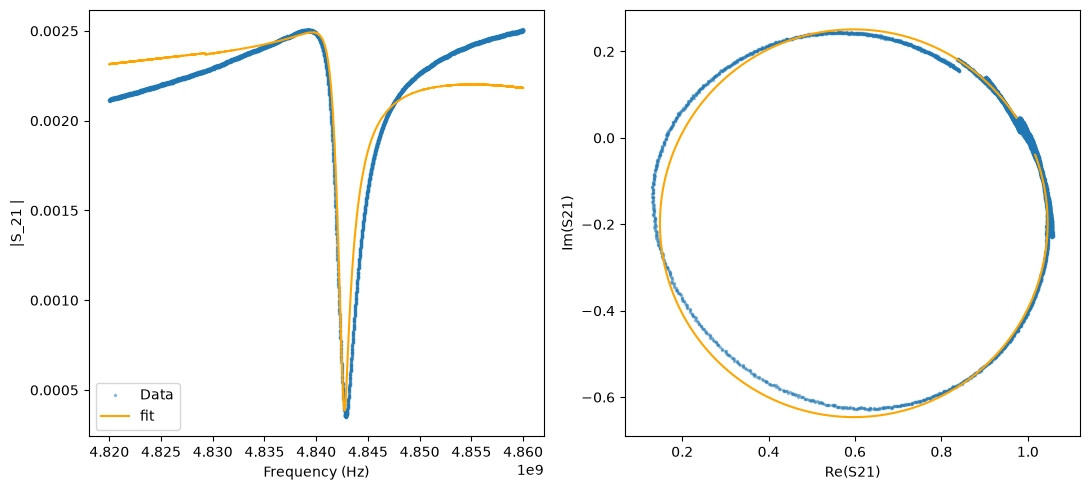

In [38]:

fit = circuit.notch_port()
fit.add_data(freq, s21_complex)
fit.autofit()

z_raw  = fit.z_data_raw      # as-measured — still has delay/background, will spiral
z_norm = fit.z_data          # delay/background-corrected — this is what circlefit() actually fits
z_sim  = fit.z_data_sim      # library's fitted curve, reconstructed back in RAW space

lor_data = z_sim/(np.exp(1j * phase_rad))

# Recover that same fitted curve in NORMALIZED space by dividing out the identical
# background factor that turns z_data_raw into z_data — avoids re-deriving phi0/theta0 by hand
background = z_raw / z_norm
z_sim_norm = z_sim / background

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].plot(freq, mag_lin, '.', ms=3, alpha=0.4, label='Data')
axes[0].plot(freq, lor_data, '-', color='orange', label='fit')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel(rf'|S_21 |')
axes[0].legend(loc='best')



axes[1].plot(z_norm.real, z_norm.imag, '.', ms=3, alpha=0.4, label='Data')
axes[1].plot(z_sim_norm.real, z_sim_norm.imag, '-', color='orange', label='Fit')

axes[1].set_xlabel('Re(S21)'); axes[1].set_ylabel('Im(S21)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

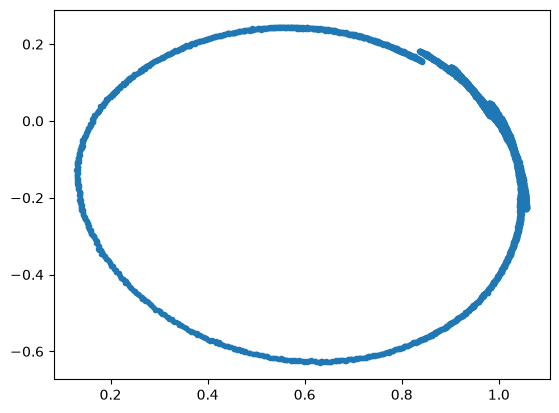

In [24]:

fit = circuit.notch_port()
fit.add_data(freq, s21_complex)
fit.autofit()

data = fit.z_data

plt.plot(data.real,data.imag,'.')

